# 02 · Modelos: baseline para predecir mortalidad según lluvia

**Curso:** Inteligencia Artificial Aplicada (1INF62) · PUCP · 2026-2 · Entregable parcial (Semana 8)

Requiere haber ejecutado antes `01_eda.ipynb` (genera `data/processed/accidentes_clima.csv`).

## Formulación del problema
El dataset solo contiene accidentes **ya ocurridos**, por lo que las preguntas que el modelo puede responder son:

| Tarea | Pregunta | Variable objetivo | Baseline de este entregable |
|---|---|---|---|
| **A · Clasificación** | Dado un accidente en cierto lugar/hora/lluvia, ¿es fatal? | `ES_FATAL` (`NUM_FALLECIDOS ≥ 1`) | Regresión logística |
| **B · Regresión de conteo** | ¿Cuántos fallecidos se esperan en ese accidente? | `NUM_FALLECIDOS` | Regresión de Poisson |

**Dos conjuntos de variables**
- **Set A (ex-ante):** lluvia del día en el punto del accidente (o en la capital, si no se pudo ubicar; ver `01_eda.ipynb`, sección 2), altitud del punto (`ELEVACION`), hora, mes, día de la semana, departamento, código de vía, kilómetro. No incluye información que solo se conoce después del accidente.
- **Set B (A + `MODALIDAD`):** agrega el tipo de accidente (atropello, choque, despiste, volcadura…). Es muy informativo pero **solo se conoce una vez ocurrido** el accidente; se reporta como referencia.

**Métricas** (clase positiva muy minoritaria → no usar solo *accuracy*): ROC-AUC, PR-AUC (*average precision*), F1, precision, recall y balanced accuracy. Para conteos: MAE, RMSE y devianza de Poisson frente a un modelo constante.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.metrics import (average_precision_score, balanced_accuracy_score, ConfusionMatrixDisplay, f1_score,
                             mean_absolute_error, mean_poisson_deviance, mean_squared_error, precision_score,
                             recall_score, roc_auc_score, PrecisionRecallDisplay, RocCurveDisplay)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
SEED = 42

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC, PLOTS, RESULTS = ROOT / "data" / "processed", ROOT / "results" / "plots", ROOT / "results"
PLOTS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROC / "accidentes_clima.csv", parse_dates=["FECHA"])
df = df.dropna(subset=["precipitation_sum"]).reset_index(drop=True)
print(df.shape, f"| % fatal = {100 * df.ES_FATAL.mean():.2f}%")

(8110, 25) | % fatal = 11.73%


## 1. Preparación de variables

In [2]:
df["PRECIP_LOG"] = np.log1p(df["precipitation_sum"])             # la lluvia está muy sesgada → log1p
df["HORA_SIN"] = np.sin(2 * np.pi * df["HORA_INT"] / 24)         # hora como variable cíclica
df["HORA_COS"] = np.cos(2 * np.pi * df["HORA_INT"] / 24)
df["MES_SIN"] = np.sin(2 * np.pi * df["MES"] / 12)
df["MES_COS"] = np.cos(2 * np.pi * df["MES"] / 12)
df["DIA_SEMANA"] = df["DIA_SEMANA"].astype(str)

NUM = ["PRECIP_LOG", "ELEVACION", "HORA_SIN", "HORA_COS", "MES_SIN", "MES_COS", "KILOMETRO"]  # ELEVACION: hallazgo del EDA (4.4)
CAT_A = ["DEPARTAMENTO", "DIA_SEMANA", "CODIGO_VIA"]
CAT_B = CAT_A + ["MODALIDAD"]


def make_pre(cat_cols):
    num = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])
    cat = Pipeline([("oh", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=30))])
    return ColumnTransformer([("num", num, NUM), ("cat", cat, cat_cols)])


# Partición estratificada 80/20 (misma para todos los modelos)
idx_tr, idx_te = train_test_split(df.index, test_size=0.2, stratify=df["ES_FATAL"], random_state=SEED)
tr, te = df.loc[idx_tr], df.loc[idx_te]
print("train:", len(tr), "| test:", len(te), "| % fatal train/test:",
      round(100 * tr.ES_FATAL.mean(), 2), "/", round(100 * te.ES_FATAL.mean(), 2))

train: 6488 | test: 1622 | % fatal train/test: 11.73 / 11.71


## 2. Tarea A — Clasificación (¿accidente fatal?)

In [3]:
def evaluar_clf(nombre, modelo, cols, split="aleatorio 80/20", tr_=None, te_=None):
    tr_ = tr if tr_ is None else tr_
    te_ = te if te_ is None else te_
    modelo.fit(tr_[cols], tr_["ES_FATAL"])
    prob = modelo.predict_proba(te_[cols])[:, 1]
    pred = (prob >= 0.5).astype(int)
    y = te_["ES_FATAL"]
    return dict(tarea="A_clasificacion", modelo=nombre, split=split,
                roc_auc=roc_auc_score(y, prob), pr_auc=average_precision_score(y, prob),
                f1=f1_score(y, pred), precision=precision_score(y, pred, zero_division=0),
                recall=recall_score(y, pred), balanced_acc=balanced_accuracy_score(y, pred),
                prevalencia_test=y.mean()), modelo, prob


def lr_pipe(cat_cols):
    return Pipeline([("pre", make_pre(cat_cols)),
                     ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", C=1.0))])


res = []
r0, _, _ = evaluar_clf("Dummy (prior)", Pipeline([("pre", make_pre(CAT_A)),
                                                    ("clf", DummyClassifier(strategy="prior"))]), NUM + CAT_A)
r1, lr_A, prob_A = evaluar_clf("Reg. logística · Set A (ex-ante)", lr_pipe(CAT_A), NUM + CAT_A)
r2, lr_B, prob_B = evaluar_clf("Reg. logística · Set B (+ MODALIDAD)", lr_pipe(CAT_B), NUM + CAT_B)
res += [r0, r1, r2]

# Validación cruzada estratificada (5 folds) sobre el set de entrenamiento: PR-AUC
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
for nombre, pipe, cols in [("Reg. logística · Set A", lr_pipe(CAT_A), NUM + CAT_A),
                           ("Reg. logística · Set B", lr_pipe(CAT_B), NUM + CAT_B)]:
    s = cross_val_score(pipe, tr[cols], tr["ES_FATAL"], cv=cv, scoring="average_precision")
    print(f"CV 5-fold PR-AUC · {nombre}: {s.mean():.3f} ± {s.std():.3f}")

pd.DataFrame(res).set_index("modelo").round(3)

CV 5-fold PR-AUC · Reg. logística · Set A: 0.159 ± 0.011


CV 5-fold PR-AUC · Reg. logística · Set B: 0.260 ± 0.023


,tarea,split,roc_auc,pr_auc,f1,precision,recall,balanced_acc,prevalencia_test
modelo,,,,,,,,,
Dummy (prior),A_clasificacion,aleatorio 80/20,0.500,0.117,0.000,0.000,0.000,0.500,0.117
Reg. logística · Set A (ex-ante),A_clasificacion,aleatorio 80/20,0.616,0.186,0.247,0.155,0.605,0.584,0.117
Reg. logística · Set B (+ MODALIDAD),A_clasificacion,aleatorio 80/20,0.658,0.256,0.262,0.174,0.532,0.598,0.117


In [4]:
# Robustez: partición TEMPORAL (entrena con lo anterior al percentil 80 de fechas, prueba con lo posterior)
corte = df["FECHA"].quantile(0.8)
tr_t, te_t = df[df.FECHA < corte], df[df.FECHA >= corte]
rt, _, _ = evaluar_clf("Reg. logística · Set A", lr_pipe(CAT_A), NUM + CAT_A,
                       split=f"temporal (corte {corte.date()})", tr_=tr_t, te_=te_t)
res.append(rt)
pd.DataFrame([rt]).set_index("modelo").round(3)

,tarea,split,roc_auc,pr_auc,f1,precision,recall,balanced_acc,prevalencia_test
modelo,,,,,,,,,
Reg. logística · Set A,A_clasificacion,temporal (corte 2021-06-24),0.6,0.163,0.231,0.145,0.571,0.574,0.112


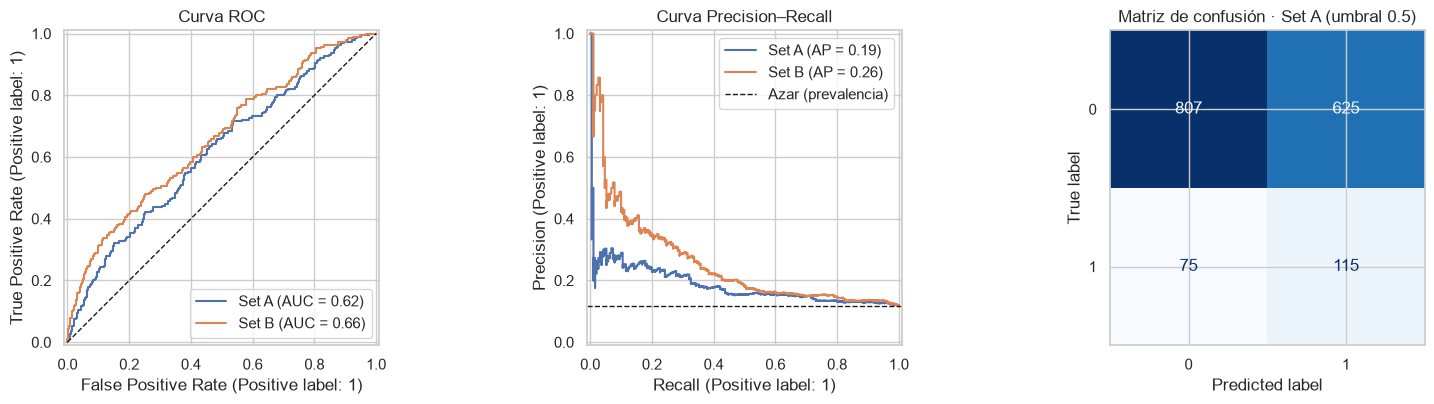

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
yte = te["ES_FATAL"]
RocCurveDisplay.from_predictions(yte, prob_A, name="Set A", ax=ax[0])
RocCurveDisplay.from_predictions(yte, prob_B, name="Set B", ax=ax[0]); ax[0].plot([0, 1], [0, 1], "k--", lw=1)
ax[0].set_title("Curva ROC")
PrecisionRecallDisplay.from_predictions(yte, prob_A, name="Set A", ax=ax[1])
PrecisionRecallDisplay.from_predictions(yte, prob_B, name="Set B", ax=ax[1])
ax[1].axhline(yte.mean(), color="k", ls="--", lw=1, label="Azar (prevalencia)"); ax[1].legend(); ax[1].set_title("Curva Precision–Recall")
ConfusionMatrixDisplay.from_predictions(yte, (prob_A >= 0.5).astype(int), ax=ax[2], colorbar=False, cmap="Blues")
ax[2].set_title("Matriz de confusión · Set A (umbral 0.5)")
plt.tight_layout(); plt.savefig(PLOTS / "modelo_01_baseline_clasificacion.png", dpi=150); plt.show()

### 2.1 Respuesta del modelo a la lluvia: P(fatal) según mm de precipitación

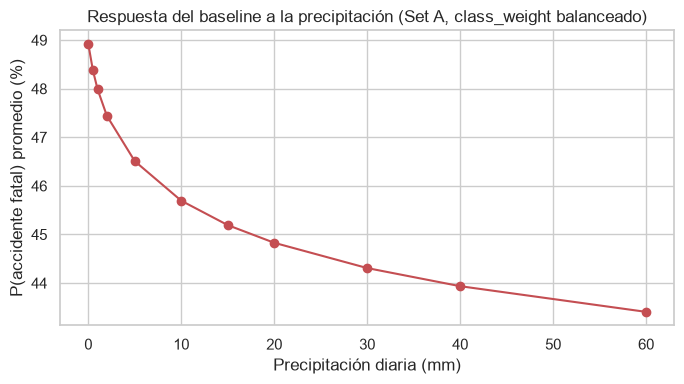

Nota: con class_weight='balanced' las probabilidades están infladas; lo informativo es la FORMA de la curva.


In [6]:
# Efecto marginal promedio (tipo gráfico de dependencia parcial): se fija la lluvia en cada valor
# y se promedia la probabilidad predicha sobre las demás características del conjunto de prueba.
# OJO: describe una ASOCIACIÓN aprendida por el modelo, no un efecto causal.
grid_mm = np.array([0, 0.5, 1, 2, 5, 10, 15, 20, 30, 40, 60])
base = te[NUM + CAT_A].copy()
curva = []
for mm in grid_mm:
    tmp = base.copy(); tmp["PRECIP_LOG"] = np.log1p(mm)
    curva.append(lr_A.predict_proba(tmp)[:, 1].mean())

plt.figure(figsize=(7, 4))
plt.plot(grid_mm, 100 * np.array(curva), marker="o", color="#C44E52")
plt.xlabel("Precipitación diaria (mm)"); plt.ylabel("P(accidente fatal) promedio (%)")
plt.title("Respuesta del baseline a la precipitación (Set A, class_weight balanceado)")
plt.tight_layout(); plt.savefig(PLOTS / "modelo_02_curva_lluvia.png", dpi=150); plt.show()
print("Nota: con class_weight='balanced' las probabilidades están infladas; lo informativo es la FORMA de la curva.")

In [7]:
# Significancia de la lluvia con un logit clásico (interpretable): controla por departamento y hora,
# y luego también por altitud (en el EDA, lluvia y altitud van juntas)
import statsmodels.formula.api as smf
dl = df.dropna(subset=["HORA_SIN"]).assign(ELEV_KM=lambda x: x.ELEVACION / 1000)
for nombre, f in [("depto + hora", "ES_FATAL ~ PRECIP_LOG + HORA_SIN + HORA_COS + C(DEPARTAMENTO)"),
                  ("depto + hora + altitud", "ES_FATAL ~ PRECIP_LOG + ELEV_KM + HORA_SIN + HORA_COS + C(DEPARTAMENTO)")]:
    m = smf.logit(f, data=dl).fit(disp=0)
    for v in ["PRECIP_LOG", "ELEV_KM"]:
        if v in m.params:
            ic = np.exp(m.conf_int().loc[v])
            print(f"[{nombre}] OR {v}: {np.exp(m.params[v]):.3f} (IC95% {ic[0]:.3f}–{ic[1]:.3f}), p = {m.pvalues[v]:.4g}")

[depto + hora] OR PRECIP_LOG: 0.929 (IC95% 0.847–1.018), p = 0.1139
[depto + hora + altitud] OR PRECIP_LOG: 0.980 (IC95% 0.891–1.077), p = 0.6698
[depto + hora + altitud] OR ELEV_KM: 0.855 (IC95% 0.796–0.918), p = 1.702e-05


## 3. Tarea B — Regresión de conteo (fallecidos por accidente)

In [8]:
def evaluar_reg(nombre, modelo, cols):
    modelo.fit(tr[cols], tr["NUM_FALLECIDOS"])
    pred = np.clip(modelo.predict(te[cols]), 1e-6, None)
    y = te["NUM_FALLECIDOS"]
    return dict(tarea="B_regresion_conteo", modelo=nombre, split="aleatorio 80/20",
                mae=mean_absolute_error(y, pred), rmse=np.sqrt(mean_squared_error(y, pred)),
                poisson_deviance=mean_poisson_deviance(y.clip(lower=0), pred)), modelo, pred


dummy_r, _, _ = evaluar_reg("Dummy (media)", Pipeline([("pre", make_pre(CAT_A)), ("reg", DummyRegressor(strategy="mean"))]), NUM + CAT_A)
pois_r, pois, pred_pois = evaluar_reg("Regresión de Poisson · Set A",
                                      Pipeline([("pre", make_pre(CAT_A)), ("reg", PoissonRegressor(alpha=1e-3, max_iter=1000))]),
                                      NUM + CAT_A)
res += [dummy_r, pois_r]
pd.DataFrame([dummy_r, pois_r]).set_index("modelo").round(4)

,tarea,split,mae,rmse,poisson_deviance
modelo,,,,,
Dummy (media),B_regresion_conteo,aleatorio 80/20,0.3014,0.7934,0.8470
Regresión de Poisson · Set A,B_regresion_conteo,aleatorio 80/20,0.2958,0.7915,0.8245


,accidentes,observado,predicho
bin,,,
0 mm,801,0.1910,0.1879
0–1,307,0.1336,0.1638
1–5,285,0.1579,0.1516
5–10,130,0.1538,0.1511
10–20,76,0.2237,0.1380
>20,23,0.1304,0.1248


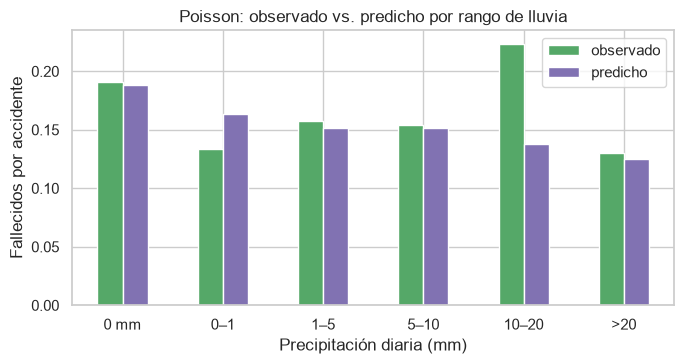

In [9]:
# Calibración por rango de lluvia: fallecidos por accidente observados vs. predichos
BINS = [-1, 0, 1, 5, 10, 20, np.inf]; ETIQ = ["0 mm", "0–1", "1–5", "5–10", "10–20", ">20"]
cal = te.assign(pred=pred_pois, bin=pd.cut(te.precipitation_sum, bins=BINS, labels=ETIQ))
cal = cal.groupby("bin", observed=True).agg(accidentes=("pred", "size"), observado=("NUM_FALLECIDOS", "mean"),
                                            predicho=("pred", "mean"))
display(cal.round(4))
cal[["observado", "predicho"]].plot.bar(figsize=(7, 3.8), color=["#55A868", "#8172B2"])
plt.ylabel("Fallecidos por accidente"); plt.xlabel("Precipitación diaria (mm)"); plt.xticks(rotation=0)
plt.title("Poisson: observado vs. predicho por rango de lluvia")
plt.tight_layout(); plt.savefig(PLOTS / "modelo_03_poisson_calibracion.png", dpi=150); plt.show()

## 4. Tabla de métricas del baseline

In [10]:
metricas = pd.DataFrame(res)
metricas.round(4).to_csv(RESULTS / "metrics.csv", index=False)
print("Guardado:", RESULTS / "metrics.csv")
metricas.round(3)

Guardado: C:\Users\angel\Documentos\30_PUCP\2026-2\IAA-Grupo3\results\metrics.csv


,tarea,modelo,split,roc_auc,pr_auc,f1,precision,recall,balanced_acc,prevalencia_test,mae,rmse,poisson_deviance
0,A_clasificacion,Dummy (prior),aleatorio 80/20,0.500,0.117,0.000,0.000,0.000,0.500,0.117,NaN,NaN,NaN
1,A_clasificacion,Reg. logística · Set A (ex-ante),aleatorio 80/20,0.616,0.186,0.247,0.155,0.605,0.584,0.117,NaN,NaN,NaN
2,A_clasificacion,Reg. logística · Set B (+ MODALIDAD),aleatorio 80/20,0.658,0.256,0.262,0.174,0.532,0.598,0.117,NaN,NaN,NaN
3,A_clasificacion,Reg. logística · Set A,temporal (corte 2021-06-24),0.600,0.163,0.231,0.145,0.571,0.574,0.112,NaN,NaN,NaN
4,B_regresion_conteo,Dummy (media),aleatorio 80/20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.301,0.793,0.847
5,B_regresion_conteo,Regresión de Poisson · Set A,aleatorio 80/20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.296,0.792,0.824


## 5. Lectura del baseline

- **Supera al trivial, pero por poco:** PR-AUC 0.186 frente a 0.117 del Dummy (≈ 1.6 veces el azar; CV 0.159 ± 0.011). Detecta el 61 % de los fatales, pero con precisión baja (≈ 16 de cada 100 marcados lo son). Poisson mejora la devianza del Dummy solo ≈ 2.6 %.
- **La lluvia no aporta; la altitud sí:** con control por departamento y hora, el OR de log(1 + lluvia) es 0.929 (p = 0.11); al agregar la altitud pasa a **0.980 (p = 0.67)**, y cada 1 000 m reducen las odds de fatalidad (OR 0.855, p < 0.001). Confirma el hallazgo del EDA (4.4): el signo negativo de la lluvia venía de la geografía.
- **Set B:** `MODALIDAD` sube la PR-AUC a 0.256, pero solo se conoce después del accidente → referencia, no modelo ex-ante.
- **Partición temporal:** PR-AUC 0.163 (prevalencia 0.112), sin deterioro fuerte.
- **Limitaciones:** asociaciones, no causas; reanálisis de ~11 km y 19.8 % con lluvia de la capital; solo hay accidentes (sin tráfico); modelo lineal sin interacciones.
- **Siguientes pasos:** modelos no lineales (árbol, KNN, MLP), binomial negativa, interacciones lluvia × altitud y lluvia × departamento, ajuste de umbral o remuestreo.


## 6. Modelos propuestos para el Entregable Final

| Modelo | Tipo | Respaldo en literatura / curso |
|---|---|---|
| Regresión logística con penalización L1 (Lasso) | Clasificación | Babaoglu y Babaoglu (2021) |
| Árbol de decisión | Clasificación y regresión | Curso; Muñoz et al. (2024) interpretan árboles e importancia de variables (Random Forest) |
| KNN | Clasificación y regresión | Curso |
| MLP | Clasificación y regresión | Curso; Emu et al. (2022) usan redes profundas |
| Regresión binomial negativa / Poisson | Conteo de fallecidos | Mhetre & Thube (2023) |
| Manejo de desbalance (`class_weight`, ensambles por votación) | Preprocesamiento | Emu et al. (2022) |
| K-Means de departamentos por lluvia y siniestralidad (+ PCA para visualizar) | Variable espacial / EDA | Muñoz et al. (2024) |
| Vista agregada departamento-día | Regresión | EDA + Mhetre & Thube (2023) |
